# Multiple Fleets Plots - Mode Shares and Wait Times

**Author:** Carlos Guirado   
**Objective:** Imports csv files consolidated by Solo/Pooled RH and time period and produces summaries and plots.

In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

## 1. Global Plot Styles

Define consistent styling parameters for all plots

In [26]:
# Global plot parameters
PLOT_STYLES = {
    'figure_size': (11.7, 8.27),
    'grid_style': ':',
    'legend_font_size': 22,
    'tick_font_size': 22,
    'marker_size': 18,
    'marker_style': '.',
    'line_width': 3.0,
    'label_size': 22,
    'font_size': 18,
    'colors': {
        'solo': 'b',
        'pooled': 'darkorange'
    }
}

def set_plot_styles():
    """Set global matplotlib and seaborn plot styles"""
    sns.set(rc={'figure.figsize': PLOT_STYLES['figure_size']})
    sns.set_style("whitegrid", {"grid.linestyle": PLOT_STYLES['grid_style']})
    plt.rc('legend', fontsize=PLOT_STYLES['legend_font_size'])
    plt.rc('xtick', labelsize=PLOT_STYLES['tick_font_size'])
    plt.rc('ytick', labelsize=PLOT_STYLES['tick_font_size'])

# Set styles
set_plot_styles()

## 2. Data Processing Functions

Functions to load and process the wait times data

In [27]:
def process_wait_times(period='pm'):
    """Process wait time data for both pooled and solo rides"""
    # Generate run numbers
    runs = pd.Series(range(3, 45)).repeat(8).tolist()
    
    # Process pooled data
    df_pooled = pd.read_csv(f'all_waits_pooled_{period}.csv')
    df_pooled['run'] = runs
    df_pooled = df_pooled.pivot(index='run', columns='Unnamed: 0', values='1')
    
    # Process solo data
    df_solo = pd.read_csv(f'all_waits_solo_{period}.csv')
    df_solo['run'] = runs
    df_solo = df_solo.pivot(index='run', columns='Unnamed: 0', values='1')
    
    return df_pooled, df_solo

def add_metadata_columns(df_solo, df_pooled, metadata):
    """Add metadata columns to dataframes"""
    df_solo_copy = df_solo.copy()
    df_pooled_copy = df_pooled.copy()
    
    for df in [df_solo_copy, df_pooled_copy]:
        for key, value in metadata.items():
            df[key] = value
        
    df_solo_copy['Type'] = 'RH solo'
    df_pooled_copy['Type'] = 'RH pooled'
    
    # Convert percentage strings to floats
    percentage_cols = ['price_solo', 'price_pooled', 'size']
    for df in [df_solo_copy, df_pooled_copy]:
        for col in percentage_cols:
            df[col] = df[col].str.rstrip('%').astype(float)/100
            
    return df_solo_copy, df_pooled_copy

def calculate_baseline_differences(df):
    """Calculate percentage differences from baseline"""
    df_copy = df.copy()
    df_copy['pc_diff_mean'] = ((df_copy['mean']-df_copy['mean'].iloc[1])/df_copy['mean'].iloc[1]*100)
    df_copy['pc_diff'] = ((df_copy['50%']-df_copy['50%'].iloc[1])/df_copy['50%'].iloc[1]*100)
    
    df_copy['pc_diff_mean_wrt_baseline'] = float('nan')
    
    for size in df_copy['size'].unique():
        for n_fleet in df_copy['n_fleets'].unique():
            for ride_type, type_label in [('RH solo', 'solo'), ('RH pooled', 'pooled')]:
                mask = (df_copy['Type'] == ride_type) & (df_copy['size'] == size) & (df_copy['n_fleets'] == n_fleet)
                baseline_mask = mask & (df_copy[f'price_{type_label}'] == 1.0)
                
                if any(baseline_mask):
                    baseline_mean = df_copy.loc[baseline_mask, 'mean'].iloc[0]
                    df_copy.loc[mask, 'pc_diff_mean_wrt_baseline'] = (
                        (df_copy.loc[mask, 'mean'] - baseline_mean) / baseline_mean * 100
                    )
    
    return df_copy

## 3. Plotting Functions

Functions to create the various plots

In [28]:
def plot_wait_times_comparison(df_joint, n_fleets=2):
    """Plot wait times comparison for both solo and pooled rides"""
    fig, ax = plt.subplots()
    
    for ride_type, color in [('RH solo', PLOT_STYLES['colors']['solo']), 
                            ('RH pooled', PLOT_STYLES['colors']['pooled'])]:
        sns.lineplot(
            data=df_joint.loc[(df_joint['n_fleets'] == n_fleets) & 
                             (df_joint['Type'] == ride_type) &
                             (df_joint['price_solo'] == 1) & 
                             (df_joint['price_pooled'] == 1)],
            x="size", 
            y="pc_diff",
            marker=PLOT_STYLES['marker_style'],
            markersize=PLOT_STYLES['marker_size'],
            color=color,
            label=f'{ride_type}, {n_fleets} fleets'
        )
    
    ax.set_xticks([1.0, 1.6, 2.0, 3.0, 4.0])
    plt.ylabel('Median wait time in the PM\nChange with respect to baseline (%)', 
              size=PLOT_STYLES['label_size'])
    plt.xlabel('Total fleet size multiplier', size=PLOT_STYLES['label_size'])
    plt.legend(fontsize=PLOT_STYLES['font_size'])
    plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0%}'))
    plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.1f}'))
    
    plt.savefig('wait_times_two_fleets.eps', bbox_inches='tight', format='eps', transparent=False)
    return fig

def plot_mode_shares_comparison(constant_price_df, n_fleets=2):
    """Plot mode shares comparison for both solo and pooled rides"""
    fig, ax = plt.subplots()
    
    constant_price = constant_price_df[constant_price_df['Total fleet size'] < 5].copy()
    
    # Calculate percentage differences
    constant_price.loc[:, 'rh_solo_share_pc_diff'] = (
        (constant_price['Trip Exec Share Ride Hail'] - 
         constant_price['Trip Exec Share Ride Hail'].iloc[1]) / 
        constant_price['Trip Exec Share Ride Hail'].iloc[1]
    )
    constant_price.loc[:, 'rh_pooled_share_pc_diff'] = (
        (constant_price['Trip Exec Share Ride Hail Pooled'] - 
         constant_price['Trip Exec Share Ride Hail Pooled'].iloc[1]) / 
        constant_price['Trip Exec Share Ride Hail Pooled'].iloc[1]
    )
    
    for ride_type, y_col, color in [
        ('RH Solo', 'rh_solo_share_pc_diff', PLOT_STYLES['colors']['solo']),
        ('RH Pooled', 'rh_pooled_share_pc_diff', PLOT_STYLES['colors']['pooled'])
    ]:
        sns.lineplot(
            data=constant_price.loc[(constant_price['Number of fleets'] == n_fleets) & 
                                  (constant_price['RH Solo Price'] == 1) & 
                                  (constant_price['RH Pooled Price'] == 1)],
            x="Total fleet size", 
            y=y_col,
            marker=PLOT_STYLES['marker_style'],
            markersize=PLOT_STYLES['marker_size'],
            color=color,
            label=f'{ride_type}, {n_fleets} fleets'
        )
    
    ax.set_xticks([1.0, 1.6, 2.0, 3.0, 4.0])
    plt.ylabel('Mode shares\nDifference with respect to baseline (%)', 
              size=PLOT_STYLES['label_size'])
    plt.xlabel('Total fleet size multiplier', size=PLOT_STYLES['label_size'])
    plt.legend(fontsize=PLOT_STYLES['font_size'])
    plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0%}'))
    plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.1f}'))
    
    plt.savefig('mode_shares_two_fleets.eps', bbox_inches='tight', format='eps', transparent=False)
    return fig

def plot_price_impact(all_data_df, fleet_sizes=[1, 2, 4], n_fleets=5):
    """Plot impact of price on mode shares"""
    fig, ax = plt.subplots()
    
    all_data = all_data_df[
        (all_data_df['RH Pooled Price'] > 0) & 
        (all_data_df['RH Solo Price'] > 0)
    ].copy()
    
    # Calculate baseline differences
    baseline_indices = {
        1: 2,  # fleet size 1, index 2
        2: 4,  # fleet size 2, index 4
        4: 5   # fleet size 4, index 5
    }
    
    for size in fleet_sizes:
        baseline_idx = baseline_indices[size]
        all_data.loc[:, f'rh_solo_share_pc_diff_size_{size}'] = (
            (all_data['Trip Exec Share Ride Hail'] - 
             all_data['Trip Exec Share Ride Hail'].iloc[baseline_idx]) / 
            all_data['Trip Exec Share Ride Hail'].iloc[baseline_idx]
        )
        all_data.loc[:, f'rh_pooled_share_pc_diff_size_{size}'] = (
            (all_data['Trip Exec Share Ride Hail Pooled'] - 
             all_data['Trip Exec Share Ride Hail Pooled'].iloc[baseline_idx]) / 
            all_data['Trip Exec Share Ride Hail Pooled'].iloc[baseline_idx]
        )
    
    linestyles = [':', '--', '-']
    for i, size in enumerate(fleet_sizes):
        for ride_type, y_col_suffix, color in [
            ('RH solo', 'solo', PLOT_STYLES['colors']['solo']),
            ('RH pooled', 'pooled', PLOT_STYLES['colors']['pooled'])
        ]:
            sns.lineplot(
                data=all_data.loc[(all_data['Number of fleets'] == n_fleets) & 
                                 (all_data['Total fleet size'] == size)],
                x="lever_position_price",
                y=f'rh_{y_col_suffix}_share_pc_diff_size_{size}',
                marker=PLOT_STYLES['marker_style'],
                markersize=PLOT_STYLES['marker_size'],
                color=color,
                linestyle=linestyles[i],
                label=f"{ride_type}, size: {size}"
            )
    
    ax.set_xticks([0.0625, 0.27, 0.47, 1.0])
    plt.ylabel('Percent change in executed mode share\nfrom baseline price case', 
              size=PLOT_STYLES['font_size'])
    plt.xlabel('Price multiplier', size=PLOT_STYLES['font_size'])
    plt.legend(fontsize=14, frameon=True)
    plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.2f}'))
    plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.1%}'))
    
    plt.savefig('rh_price_waits.eps', bbox_inches='tight', format='eps', transparent=False)
    return fig

def plot_wait_times_by_price(df_joint, n_fleets=5):
    """Plot wait times by price for different fleet sizes"""
    plt.figure(figsize=(12, 8))
    ax = plt.gca()
    
    fleet_sizes = [1, 2, 4]
    linestyles = [':', '--', '-']
    
    for i, size in enumerate(fleet_sizes):
        for ride_type, color in [('RH solo', '#4169E1'), ('RH pooled', '#FFA500')]:
            sns.lineplot(
                data=df_joint.loc[(df_joint['n_fleets'] == n_fleets) & 
                                 (df_joint['Type'] == ride_type) & 
                                 (df_joint['size'] == size)],
                x="price_pooled",
                y='pc_diff_mean_wrt_baseline',
                color=color,
                linestyle=linestyles[i],
                marker='o',
                markersize=8,
                label=f"{ride_type}, size: {size}"
            )
    
    ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.grid(True, linestyle='-', alpha=0.2)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    ax.set_xlabel('Price multiplier', fontsize=14, labelpad=10)
    ax.set_ylabel('Percent change in average wait time (%)', fontsize=14, labelpad=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}%'))
    ax.set_ylim(0, 100)
    
    plt.legend(bbox_to_anchor=(0.98, 0.98),
              loc='upper right',
              fontsize=10,
              frameon=True,
              edgecolor='none',
              facecolor='white',
              borderaxespad=0.)
    
    plt.tight_layout()
    plt.savefig('mean_wait_times_by_price.eps', bbox_inches='tight', dpi=300, format='eps', transparent=False)
    return plt.gcf()

## 4. Main Analysis

Process the data and generate all plots

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


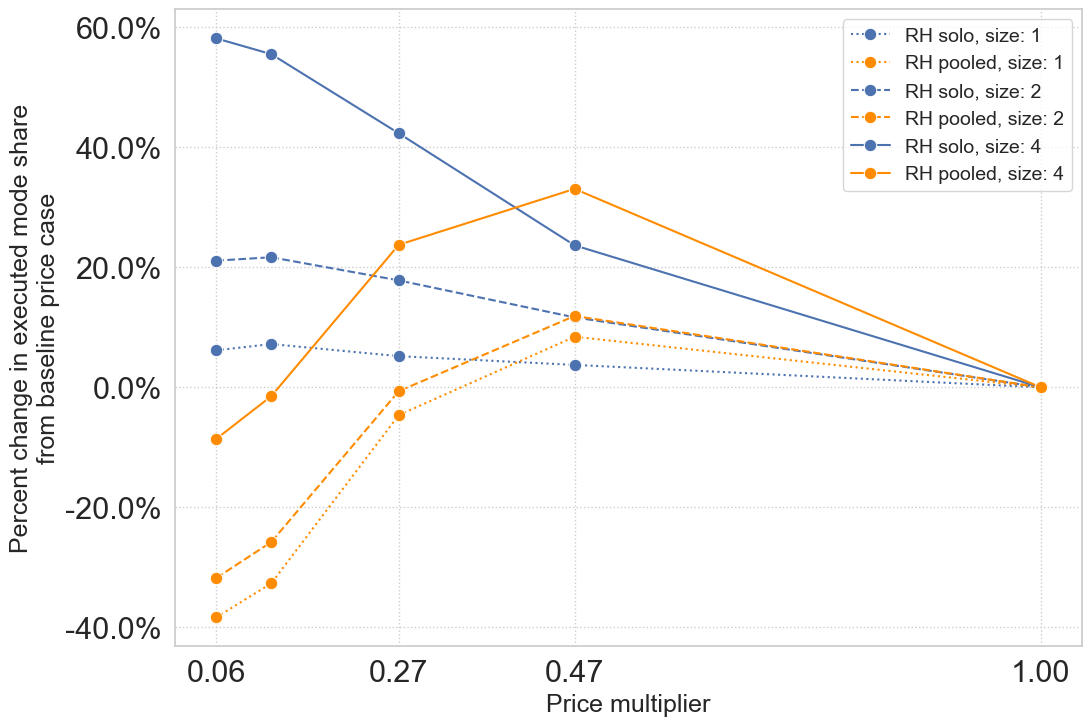

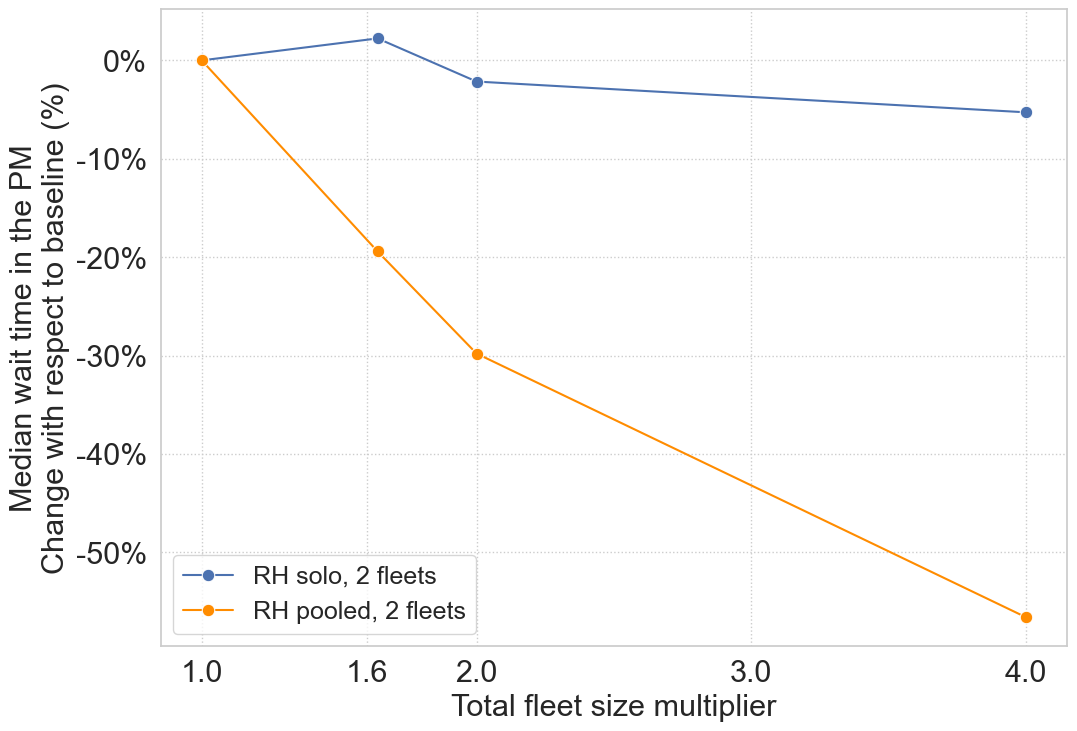

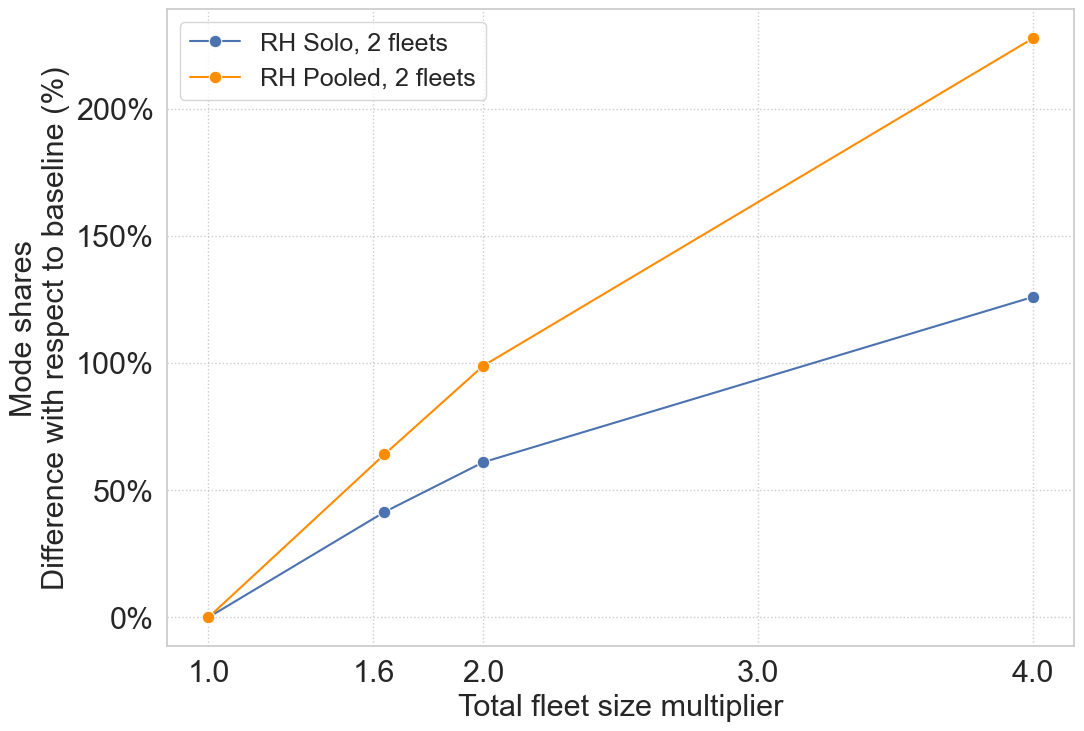

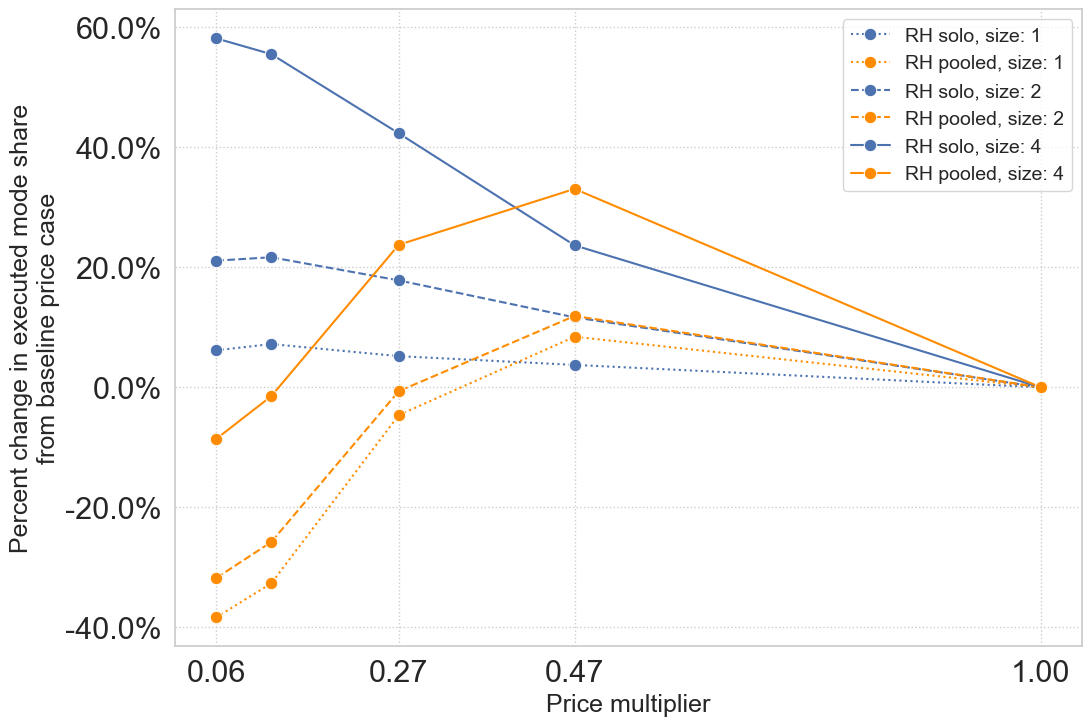

In [29]:
# Process wait times
df_pooled, df_solo = process_wait_times(period='pm')

# Load metadata
metadata = {
    'n_fleets': [1, 2, 5, 5, 5, 5, 5, 2, 2, 2, 2, 2, 5, 5, 5, 5, 5, 2, 5, 5, 5, 5, 5, 2, 5, 5, 5, 5, 5, 2, 5, 5, 5, 5, 5, 1, 2, 5, 5, 5, 5, 5],
    'size': ['100%', '100%', '100%', '164%', '200%', '400%', '1000%', '164%', '200%', '400%', '1000%', '100%', '100%', '164%', '200%', '400%', '1000%', '100%', '100%', '164%', '200%', '400%', '1000%', '100%', '100%', '164%', '200%', '400%', '1000%', '100%', '100%', '164%', '200%', '400%', '1000%', '100%', '100%', '100%', '164%', '200%', '400%', '1000%'],
    'price_solo': ['100%', '100%', '100%', '100%', '100%', '100%', '100%', '100%', '100%', '100%', '100%', '47%', '47%', '47%', '47%', '47%', '47%', '27%', '27%', '27%', '27%', '27%', '27%', '12.5%', '12.5%', '12.5%', '12.5%', '12.5%', '12.5%', '6.25%', '6.25%', '6.25%', '6.25%', '6.25%', '6.25%', '100%', '100%', '100%', '100%', '100%', '100%', '100%'],
    'price_pooled': ['100%', '100%', '100%', '100%', '100%', '100%', '100%', '100%', '100%', '100%', '100%', '47%', '47%', '47%', '47%', '47%', '47%', '27%', '27%', '27%', '27%', '27%', '27%', '12.5%', '12.5%', '12.5%', '12.5%', '12.5%', '12.5%', '6.25%', '6.25%', '6.25%', '6.25%', '6.25%', '6.25%', '0%', '0%', '0%', '0%', '0%', '0%', '0%']
}

# Process data
df_solo, df_pooled = add_metadata_columns(df_solo, df_pooled, metadata)
df_solo = calculate_baseline_differences(df_solo)
df_pooled = calculate_baseline_differences(df_pooled)

df_joint = pd.concat([df_solo, df_pooled])
df_joint = df_joint[df_joint['size'] < 5].copy()
df_joint['pc_diff'] = df_joint['pc_diff'] / 100

# Load additional data
constant_price = pd.read_csv('constant_price.csv')
all_data = pd.read_csv('all_data.csv')

# Generate plots
plot_wait_times_comparison(df_joint)
plot_mode_shares_comparison(constant_price)
plot_price_impact(all_data)
#plot_wait_times_by_price(df_joint)

In [30]:
def plot_wait_time_changes_by_price(df):
    """
    Create a line plot showing percentage changes in wait time across different
    price multipliers for various fleet sizes and ride types (RH solo and RH pooled),
    using the global style parameters defined in PLOT_STYLES.
    
    Expected DataFrame structure:
      - Row indices: 'AV Waiting Time RH Single' and 'AV Waiting Time RH Pooled'
      - Column names: '5Fl {price}Pr {size}Flz' 
        (e.g., '5Fl 1Pr 1Flz', '5Fl .47Pr 2Flz', etc.)
    """
    # Use the global figure size instead of a hard-coded (12,8)
    fig, ax = plt.subplots(figsize=PLOT_STYLES['figure_size'])
    
    # Define the price multipliers and fleet sizes (as strings, per your column names)
    prices = ['1', '.47', '.27', '.125', '.0625']
    fleet_sizes = ['1', '2', '4']
    
    # Define line styles for each fleet size
    linestyles = [':', '--', '-']
    
    # Use colors from PLOT_STYLES for the two ride types
    colors = {
        'RH solo': PLOT_STYLES['colors']['solo'],
        'RH pooled': PLOT_STYLES['colors']['pooled']
    }
    
    # Prepare a dictionary to store computed percentage changes
    # The keys are like 'solo_1', 'pooled_2', etc.
    changes = {f'solo_{size}': [] for size in fleet_sizes}
    changes.update({f'pooled_{size}': [] for size in fleet_sizes})
    
    # Use '1' (as a string) for the baseline price
    baseline_price = '1'
    for size in fleet_sizes:
        # Construct the column name for the baseline price and fleet size
        baseline_col = f'5Fl {baseline_price}Pr {size}Flz'
        baseline_solo = df.loc['AV Waiting Time RH Single', baseline_col]
        baseline_pooled = df.loc['AV Waiting Time RH Pooled', baseline_col]
        
        # Loop over the price multipliers and compute % change relative to baseline
        for price in prices:
            col = f'5Fl {price}Pr {size}Flz'
            solo_val = df.loc['AV Waiting Time RH Single', col]
            pooled_val = df.loc['AV Waiting Time RH Pooled', col]
            
            solo_change = (solo_val - baseline_solo) / baseline_solo
            pooled_change = (pooled_val - baseline_pooled) / baseline_pooled
            
            changes[f'solo_{size}'].append(solo_change)
            changes[f'pooled_{size}'].append(pooled_change)
    
    # Create x-axis values.
    # For consistency with your previous plots, convert prices to floats 
    # (with '.0625' replaced by 0.06) and then reverse the order.
    x_values = [float(p) if p != '.0625' else 0.06 for p in prices][::-1]
    
    # Loop over fleet sizes and ride types to plot each series
    for i, size in enumerate(fleet_sizes):
        for ride_type in ['RH solo', 'RH pooled']:
            key = 'solo' if ride_type == 'RH solo' else 'pooled'
            # Reverse y-values so they match the order of x_values
            y_values = changes[f'{key}_{size}'][::-1]
            ax.plot(
                x_values,
                y_values,
                marker=PLOT_STYLES['marker_style'],      # Use global marker style
                markersize=PLOT_STYLES['marker_size'],     # Use global marker size
                linestyle=linestyles[i],
                linewidth=PLOT_STYLES['line_width'],       # Use global line width
                color=colors[ride_type],
                label=f"{ride_type}, size: {size}"
            )
    
    # Set x-axis ticks and limits (consistent with your other plots)
    ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_xlim(0, 1.0)
    
    # Format the y-axis as percentages (no decimals)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x*100)}%'))
    
    # Set grid and spine positions (using global grid style)
    ax.grid(True, linestyle=PLOT_STYLES['grid_style'], alpha=0.2)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    
    # Set the axis labels using the global label size and padding
    ax.set_xlabel('Price multiplier', fontsize=PLOT_STYLES['label_size'], labelpad=10)
    ax.set_ylabel('Percent change in average wait time (%)', fontsize=PLOT_STYLES['label_size'], labelpad=10)
    
    # Set tick label sizes
    plt.xticks(fontsize=PLOT_STYLES['tick_font_size'])
    plt.yticks(fontsize=PLOT_STYLES['tick_font_size'])
    
    # Use the global legend font size
    plt.legend(bbox_to_anchor=(0.98, 0.98),
               loc='upper right',
               fontsize=PLOT_STYLES['legend_font_size'],
               frameon=True,
               edgecolor='none',
               facecolor='white',
               borderaxespad=0.)
    
    plt.tight_layout()
    # Save the figure to a file
    fig.savefig('wait_time_changes_by_price.pdf', bbox_inches='tight', format='pdf', transparent=False)
    return fig



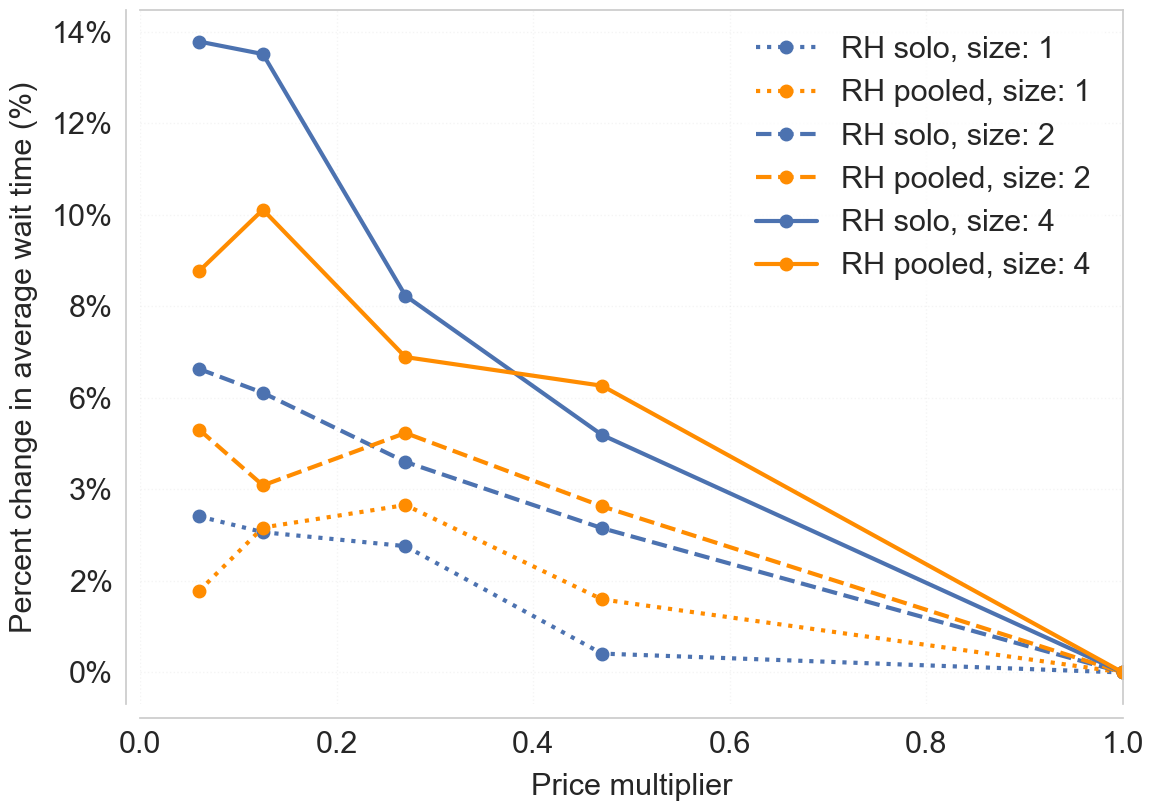

In [31]:
fig_wait_time_changes = plot_wait_time_changes_by_price(df_wait)
plt.show()
